# Name - Swatej Sonawane
# Github Username - swatejsonawane18
# USC ID - 9314761761

In [1]:
import pandas as pd
import numpy as np
import math
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import seaborn as sns

#  References

1. https://towardsdatascience.com/knn-using-scikit-learn-c6bed765be75
2. https://stackoverflow.com/questions/45670487/numpy-cov-exception-float-object-has-no-attribute-shape
3. https://stackoverflow.com/questions/52211025/knn-with-weight-set-as-distance-in-sklearn
4. https://towardsdatascience.com/9-distance-measures-in-data-science-918109d069fa


In [2]:
vertebral_data = pd.read_csv('../data/vertebral_column_data/column_2C.dat',header=None, sep=' ')
print(vertebral_data)

         0      1      2      3       4      5   6
0    63.03  22.55  39.61  40.48   98.67  -0.25  AB
1    39.06  10.06  25.02  29.00  114.41   4.56  AB
2    68.83  22.22  50.09  46.61  105.99  -3.53  AB
3    69.30  24.65  44.31  44.64  101.87  11.21  AB
4    49.71   9.65  28.32  40.06  108.17   7.92  AB
..     ...    ...    ...    ...     ...    ...  ..
305  47.90  13.62  36.00  34.29  117.45  -4.25  NO
306  53.94  20.72  29.22  33.22  114.37  -0.42  NO
307  61.45  22.69  46.17  38.75  125.67  -2.71  NO
308  45.25   8.69  41.58  36.56  118.55   0.21  NO
309  33.84   5.07  36.64  28.77  123.95  -0.20  NO

[310 rows x 7 columns]


In [3]:
headers = ['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle',
                'sacral slope', 'pelvic radius', 'grade of spondylolisthesis', 'class']
df = pd.DataFrame(columns = headers, data = vertebral_data.values)
df.loc[df['class'] == 'NO', ['class']] = 0
df.loc[df['class'] == 'AB',['class']] = 1
df

,pelvic incidence,pelvic tilt,lumbar lordosis angle,sacral slope,pelvic radius,grade of spondylolisthesis,class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.0,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.3,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1
...,...,...,...,...,...,...,...
305,47.9,13.62,36.0,34.29,117.45,-4.25,0
306,53.94,20.72,29.22,33.22,114.37,-0.42,0
307,61.45,22.69,46.17,38.75,125.67,-2.71,0
308,45.25,8.69,41.58,36.56,118.55,0.21,0


# Question 1 b i

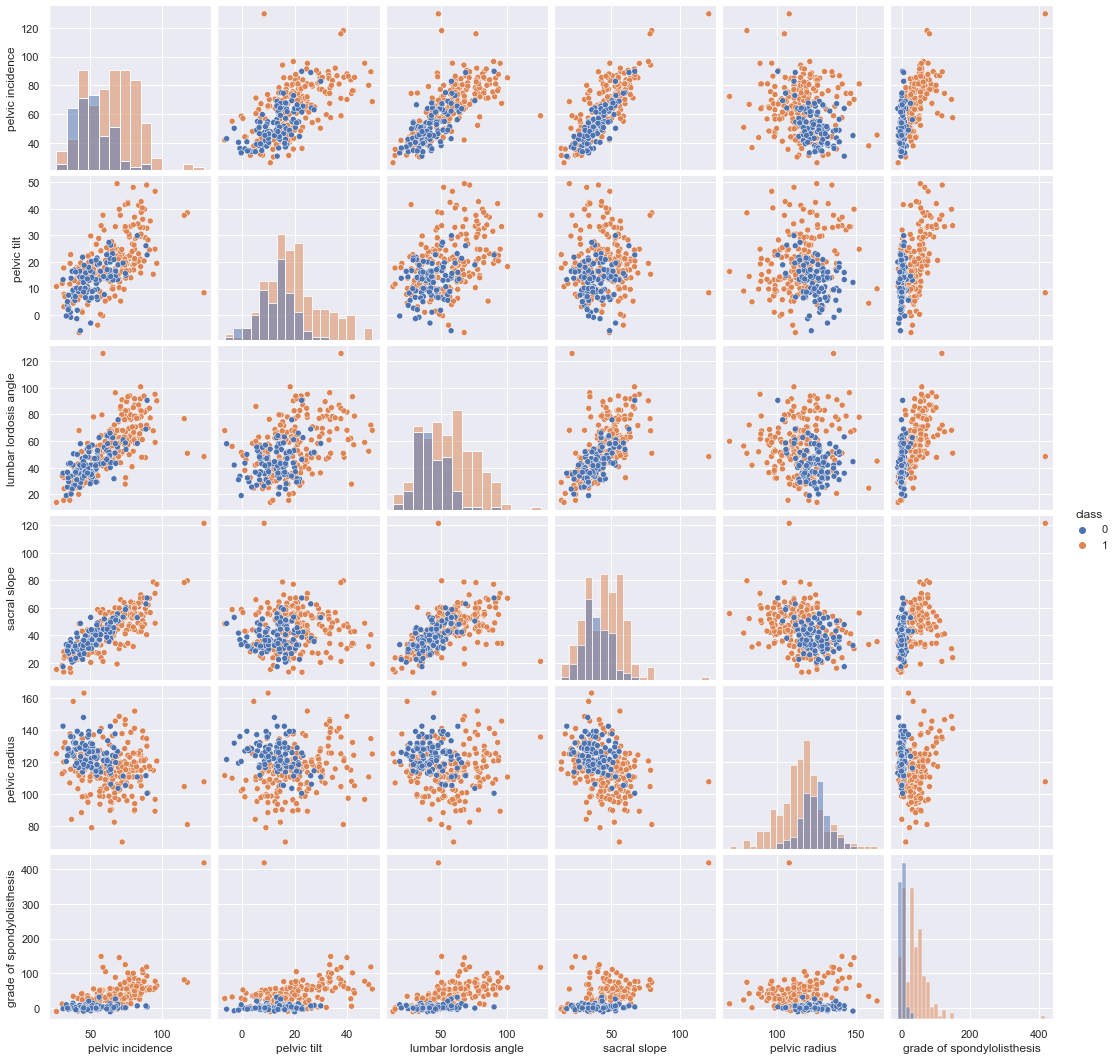

In [4]:

sns.set()
sns.pairplot(df, diag_kind='hist',hue = 'class',vars=['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle',
'sacral slope', 'pelvic radius', 'grade of spondylolisthesis'])


# Question 1 b ii

<AxesSubplot:xlabel='class', ylabel='pelvic incidence'>

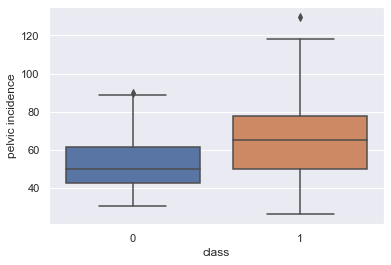

In [5]:

sns.boxplot(x=df['class'],
                y=df['pelvic incidence'],
                data=df)

<AxesSubplot:xlabel='class', ylabel='pelvic tilt'>

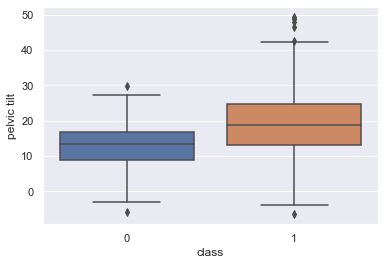

In [6]:
sns.boxplot(x=df['class'],
                y=df['pelvic tilt'],
                data=df)

<AxesSubplot:xlabel='class', ylabel='lumbar lordosis angle'>

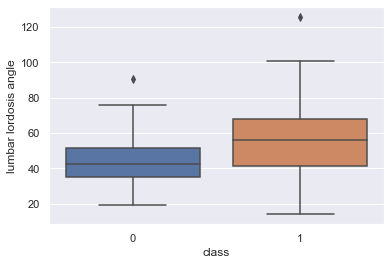

In [7]:
sns.boxplot(x=df['class'],
                y=df['lumbar lordosis angle'],
                data=df)

<AxesSubplot:xlabel='class', ylabel='sacral slope'>

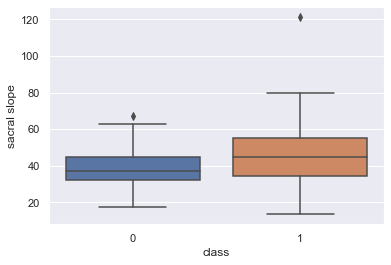

In [8]:
sns.boxplot(x=df['class'],
                y=df['sacral slope'],
                data=df)

<AxesSubplot:xlabel='class', ylabel='pelvic radius'>

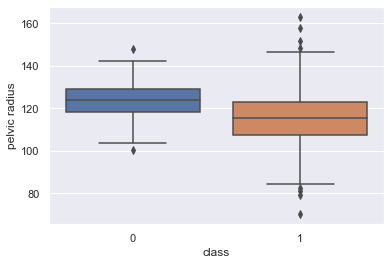

In [9]:
sns.boxplot(x=df['class'],
                y=df['pelvic radius'],
                data=df)

<AxesSubplot:xlabel='class', ylabel='grade of spondylolisthesis'>

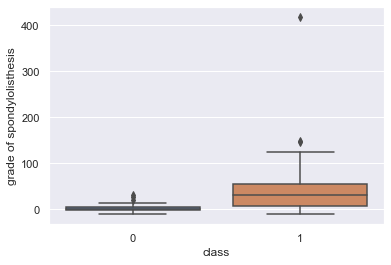

In [10]:
sns.boxplot(x=df['class'],
                y=df['grade of spondylolisthesis'],
                data=df)

# Question 1 b iii

In [11]:
df_NO=df[df['class']==0]
df_AB=df[df['class']==1]

print(df_AB)

    pelvic incidence pelvic tilt lumbar lordosis angle sacral slope  \
0              63.03       22.55                 39.61        40.48   
1              39.06       10.06                 25.02         29.0   
2              68.83       22.22                 50.09        46.61   
3               69.3       24.65                 44.31        44.64   
4              49.71        9.65                 28.32        40.06   
..               ...         ...                   ...          ...   
205            80.11       33.94                  85.1        46.17   
206            95.48       46.55                  59.0        48.93   
207            74.09       18.82                 76.03        55.27   
208            87.68       20.37                 93.82        67.31   
209            48.26       16.42                 36.33        31.84   

    pelvic radius grade of spondylolisthesis class  
0           98.67                      -0.25     1  
1          114.41                       4

In [12]:
df_NO_train = df_NO.iloc[:70]
df_NO_test = df_NO.iloc[70:]
print(df_NO_train)
print(df_NO_test)

    pelvic incidence pelvic tilt lumbar lordosis angle sacral slope  \
210            38.51       16.96                 35.11        21.54   
211            54.92       18.97                  51.6        35.95   
212            44.36        8.95                  46.9        35.42   
213            48.32       17.45                  48.0        30.87   
214             45.7       10.66                 42.58        35.04   
..               ...         ...                   ...          ...   
275            67.29       16.72                  51.0        50.57   
276            51.33       13.63                 33.26        37.69   
277            65.76       13.21                  44.0        52.55   
278            40.41       -1.33                 30.98        41.74   
279             48.8       18.02                  52.0        30.78   

    pelvic radius grade of spondylolisthesis class  
210        127.63                       7.99     0  
211        125.85                        

In [13]:
df_AB_train = df_AB.iloc[:140]
df_AB_test = df_AB.iloc[140:]


In [14]:
frames1 = [df_AB_test,df_NO_test]
dftest = pd.concat(frames1)

frames2 = [df_AB_train,df_NO_train]
dftrain = pd.concat(frames2)
print(dftrain)

    pelvic incidence pelvic tilt lumbar lordosis angle sacral slope  \
0              63.03       22.55                 39.61        40.48   
1              39.06       10.06                 25.02         29.0   
2              68.83       22.22                 50.09        46.61   
3               69.3       24.65                 44.31        44.64   
4              49.71        9.65                 28.32        40.06   
..               ...         ...                   ...          ...   
275            67.29       16.72                  51.0        50.57   
276            51.33       13.63                 33.26        37.69   
277            65.76       13.21                  44.0        52.55   
278            40.41       -1.33                 30.98        41.74   
279             48.8       18.02                  52.0        30.78   

    pelvic radius grade of spondylolisthesis class  
0           98.67                      -0.25     1  
1          114.41                       4

In [15]:
df_x_train = dftrain[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
df_y_train = dftrain['class'].astype('int')
df_x_test = dftest[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
df_y_test = dftest['class'].astype('int')

print(df_y_test)

140    1
141    1
142    1
143    1
144    1
      ..
305    0
306    0
307    0
308    0
309    0
Name: class, Length: 100, dtype: int32


# Question 1 c i

In [16]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(df_x_train, df_y_train)
test_y_predict = knn.predict(df_x_test)

In [17]:
print(test_y_predict)

[1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0
 0 0 0 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0]


In [18]:
training_score = knn.score(df_x_train, df_y_train)
test_score = knn.score(df_x_test, df_y_test)

print(metrics.accuracy_score(df_y_test,test_y_predict))
print(training_score)
print(test_score)

0.87
1.0
0.87


# Question 1 c ii

In [19]:
test_error=[]
train_error=[]
k_value=[]
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(208, 0, -3):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    test_error.append(local_test_error)
    train_error.append(local_train_error)
    k_value.append(i)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    
    
print("The best value of k:",k_best)

The best value of k: 4


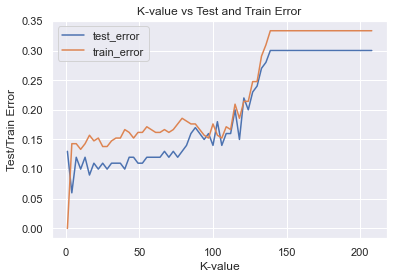

In [20]:
plt.plot(k_value, test_error, label='test_error')
plt.legend(loc="best")


plt.plot(k_value, train_error, label='train_error')
plt.legend(loc="best")

plt.title('K-value vs Test and Train Error')
plt.xlabel('K-value')
plt.ylabel('Test/Train Error')

plt.show()

Calculate the confusion matrix, true positive rate, true negative rate, precision,and F1-score when k=k∗

In [21]:

knn = KNeighborsClassifier(n_neighbors=4)

knn.fit(df_x_train, df_y_train)

test_y_predict = knn.predict(df_x_test)
tn, fp, fn, tp = confusion_matrix(df_y_test, test_y_predict).ravel()
print(classification_report(df_y_test, test_y_predict))

print("Confusion Matrix: \n ", confusion_matrix(df_y_test, test_y_predict))

TPR = tp/(tp+fn)

TNR = tn/(tn+fp)

precision = tp/(tp+fp)
recall = tp/(tp+fn)

print("Precision: ",precision)
print("Recall: ",recall)

f_score = (2*precision*recall)/(precision+recall)
print("F1-Score: ",f_score)

print("True Positive Rate: ",TPR)
print("True Negative Rate: ",TNR)


              precision    recall  f1-score   support

           0       0.96      0.83      0.89        30
           1       0.93      0.99      0.96        70

    accuracy                           0.94       100
   macro avg       0.95      0.91      0.93       100
weighted avg       0.94      0.94      0.94       100

Confusion Matrix: 
  [[25  5]
 [ 1 69]]
Precision:  0.9324324324324325
Recall:  0.9857142857142858
F1-Score:  0.9583333333333333
True Positive Rate:  0.9857142857142858
True Negative Rate:  0.8333333333333334


# Question 1 c iii

In [22]:

best_k_values=[]
n_values=[]
best_test_errors=[]
k_best=0
best_test_error=float('inf')
best_train_error = float('inf')

for n in range(10,220,10):
    n_values.append(n)
    x_trainset_0=df_NO.iloc[:math.floor(n/3)]
    x_trainset_1=df_AB.iloc[:(n-(math.floor(n/3)))]
    
    x_testset_0=df_NO.iloc[math.floor(n/3):]
    x_testset_1=df_AB.iloc[(n-(math.floor(n/3))):]
    
    frames1 = [x_trainset_0,x_trainset_1]
    x_train = pd.concat(frames1)
    
    frames2 = [x_testset_0,x_testset_1]
    x_test = pd.concat(frames2)
    
    df_x_train = x_train[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
    df_y_train = x_train['class'].astype('int')
    df_x_test = x_test[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
    df_y_test = x_test['class'].astype('int')
    
    k_best=0
    best_test_error=float('inf')
    
    for i in range(1, n, 5):
        knn = KNeighborsClassifier(n_neighbors=i)
        knn.fit(df_x_train, df_y_train)
        local_test_error = 1-knn.score(df_x_test, df_y_test)
        local_train_error = 1-knn.score(df_x_train, df_y_train)
        
        if(local_test_error<best_test_error):
            k_best=i
            best_test_error=local_test_error
        if(local_train_error<best_test_error):
            best_train_error=local_train_error
            
    best_k_values.append(k_best)
    best_test_errors.append(best_test_error)
    
    

Learning Curve

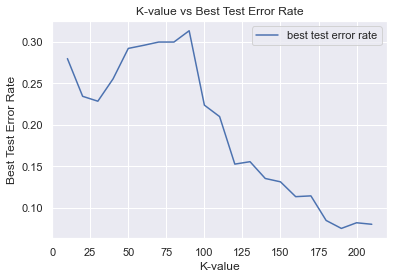

In [23]:
plt.plot(n_values, best_test_errors, label='best test error rate')
plt.legend(loc="best")

plt.title('K-value vs Best Test Error Rate')
plt.xlabel('K-value')
plt.ylabel('Best Test Error Rate')
plt.show()

# Question 1 d i A

Minkowski Distance which becomes Manhattan Distance with p = 1

In [24]:
df_x_train = dftrain[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
df_y_train = dftrain['class'].astype('int')
df_x_test = dftest[['pelvic incidence', 'pelvic tilt', 'lumbar lordosis angle', 'sacral slope', 'pelvic radius', 'grade of spondylolisthesis']]
df_y_test = dftest['class'].astype('int')

In [25]:
test_error=[]
train_error=[]
k_value=[]
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,p=1)
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    test_error.append(local_test_error)
    train_error.append(local_train_error)
    k_value.append(i)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Manhattan distance: ",k_best)
print("The best test error for Weighted KNN using Manhattan Distance: ",best_test_error)
print("The best train error for Weighted KNN using Manhattan Distance: ",best_train_error)

The best value of k for Manhattan distance:  6
The best test error for Weighted KNN using Manhattan Distance:  0.10999999999999999
The best train error for Weighted KNN using Manhattan Distance:  0.0


# Question 1 d i B

Minkowski Distance with log10(p)∈ {0.1,0.2,0.3, . . . ,1}. In this case, use the k∗ you found for the Manhattan distance in 1(d)iA. What is the best log10(p)?

In [26]:
best_test_error=float('inf')
best_train_error = float('inf')
best_log_p=0
indexs=-1
log_p=np.linspace(0.1, 1.0, 10)
p_values=list(np.logspace(0.1, 1.0, num=10))

for i in p_values:
    knn = KNeighborsClassifier(n_neighbors=6,p=i)
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    if(local_test_error<best_test_error):
        best_log_p=i
        indexs=p_values.index(i)
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
        
# print(best_log_p)
print("Best value of log p: ",log_p[indexs])

Best value of log p:  0.6


# Question 1 d i C

Minkowski Distance becomes becomes Chebyshev Distance with
p→ ∞

In [27]:
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,metric="chebyshev")
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)

    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
  
    
print("The best value of k for Chebyshev Distance: ",k_best)
print("The best test error for Chebyshev Distance: ",best_test_error)
print("The best train error for Chebyshev Distance: ",best_train_error)

The best value of k for Chebyshev Distance:  16
The best test error for Chebyshev Distance:  0.07999999999999996
The best train error for Chebyshev Distance:  0.0


# Question 1 d ii

Mahalanobis Distance

In [28]:
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,metric='mahalanobis',metric_params={'VI': np.cov(df_x_train.astype(float), rowvar=False)})
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)

    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Mahalanobis Distance: ",k_best)
print("The best test error for Mahalanobis Distance: ",best_test_error)
print("The best train error for Mahalanobis Distance:: ",best_train_error)

The best value of k for Mahalanobis Distance:  6
The best test error for Mahalanobis Distance:  0.07999999999999996
The best train error for Mahalanobis Distance::  0.0


# Question 1 e

Weighted KNN using Manhattan Distance

In [29]:

best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,p=1,weights='distance')
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Weighted KNN using Manhattan Distance: ",k_best)
print("The best test error for Weighted KNN using Manhattan Distance: ",best_test_error)
print("The best train error for Weighted KNN using Manhattan Distance: ",best_train_error)

The best value of k for Weighted KNN using Manhattan Distance:  26
The best test error for Weighted KNN using Manhattan Distance:  0.09999999999999998
The best train error for Weighted KNN using Manhattan Distance:  0.0


 Weighted KNN using Euclidean Distance

In [30]:
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,p=2,weights='distance')
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
        
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Weighted KNN using Euclidean Distance: ",k_best)
print("The best test error for Weighted KNN using Euclidean Distance: ",best_test_error)
print("The best train error for Weighted KNN using Euclidean Distance: ",best_train_error)

The best value of k for Weighted KNN using Euclidean Distance:  6
The best test error for Weighted KNN using Euclidean Distance:  0.09999999999999998
The best train error for Weighted KNN using Euclidean Distance:  0.0


Weighted KNN using Chebyshev Distance

In [31]:
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,metric='chebyshev',weights='distance')
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Weighted KNN using Chebyshev Distance: ",k_best)
print("The best test error for Weighted KNN using Chebyshev Distance: ",best_test_error)
print("The best train error for Weighted KNN using Chebyshev Distance: ",best_train_error)

The best value of k for Weighted KNN using Chebyshev Distance:  16
The best test error for Weighted KNN using Chebyshev Distance:  0.10999999999999999
The best train error for Weighted KNN using Chebyshev Distance:  0.0


# Question 1 f

In [32]:
best_test_error = float('inf')
best_train_error = float('inf')
k_best=0

for i in range(1, 200, 5):
    knn = KNeighborsClassifier(n_neighbors=i,metric='chebyshev',weights='distance')
    knn.fit(df_x_train, df_y_train)
    local_test_error = 1-knn.score(df_x_test, df_y_test)
    local_train_error = 1-knn.score(df_x_train, df_y_train)
    if(local_test_error<best_test_error):
        k_best=i
        best_test_error=local_test_error
    if(local_train_error<best_test_error):
        best_train_error=local_train_error
    
    
print("The best value of k for Weighted KNN using Chebyshev Distance: ",k_best)
print("The best test error for Weighted KNN using Chebyshev Distance: ",best_test_error)
print("The best train error for Weighted KNN using Chebyshev Distance: ",best_train_error)

The best value of k for Weighted KNN using Chebyshev Distance:  16
The best test error for Weighted KNN using Chebyshev Distance:  0.10999999999999999
The best train error for Weighted KNN using Chebyshev Distance:  0.0


The lowest train error obtained was for Weighted KNN i.e Q1 e which 0